In [ ]:
import polars as pl
import polars.selectors as cs
import seaborn as sns
import numpy as np

# Preprocessing stuff
from sklearn.preprocessing import LabelEncoder

# Model selection stuff
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV


# Classic classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Plotting stuff
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

from sklearn.metrics import confusion_matrix

# Confusion Matrices and ROC curves

In this notebook, we will ...

## Example - Kyphosis

Recall that in a previous lecture, we worked with the `kyphosis.csv`, which involved patients that may or may not have had conditions return after spinal surgery.

In [407]:
(kyphosis :=
 pl.read_csv('./data/kyphosis.csv')
   .drop('rownames')
 )

Kyphosis,Age,Number,Start
str,i64,i64,i64
"""absent""",71,3,5
"""absent""",158,3,14
"""present""",128,4,5
"""absent""",2,5,1
"""absent""",1,4,15
…,…,…,…
"""present""",157,3,13
"""absent""",26,7,13
"""absent""",120,2,13


In [408]:
(X :=
 kyphosis
 .drop('Kyphosis')
 .to_pandas()
)

,Age,Number,Start
0,71,3,5
1,158,3,14
2,128,4,5
3,2,5,1
4,1,4,15
...,...,...,...
76,157,3,13
77,26,7,13
78,120,2,13
79,42,7,6


In [409]:
(y_raw :=
 kyphosis
 .select('Kyphosis')
)

Kyphosis
str
"""absent"""
"""absent"""
"""present"""
"""absent"""
"""absent"""
…
"""present"""
"""absent"""
"""absent"""


In [410]:
(uniq_labels :=
 y_raw
 .unique() # Make sure the positive case is first
 .get_column('Kyphosis')
 .to_numpy()
)

array(['present', 'absent'], dtype=object)

In [411]:
le = LabelEncoder()
le.fit(uniq_labels)

(y_ind :=
  le.transform(y_raw.get_column('Kyphosis'))
)

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0])

#### A train/test split

The most common application of these topics is when estimating the performance of a model using test data.  While we don't have a ton of data here, let's split the data for illustration sake.

In [412]:
X_train, X_test, y_train, y_test = train_test_split(X, y_ind, test_size=0.30,random_state=306, stratify=y_ind)

## Confusion Matrix

The [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix) is a two-way table that compares the truth (true positive/negative) versus the prediction (predicted positive or negative.  The cells contain the number of occurances correspond
1. true positive,
2. true negative,
3. false positive, and
4. false negative.

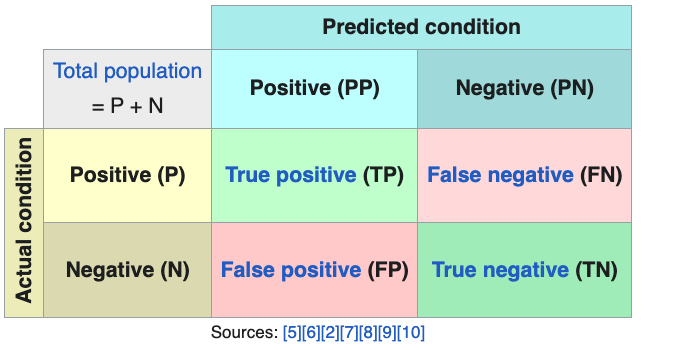
[screenshot source](https://en.wikipedia.org/wiki/Confusion_matrix)

### Example - Computing the confusion matrix for Logistic Regression.

In [371]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

(y_pred := log_reg.predict(X_test))

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0])

#### Test default `confusion_matrix` is BAD!

In [372]:
(1 - y_test).sum()

np.int64(20)

In [373]:
confusion_matrix(y_test, y_pred)

array([[19,  1],
       [ 3,  2]])

#### Better to display it with a plot from the estimated labels ...

This approach requires computing and saving the predicted classes.

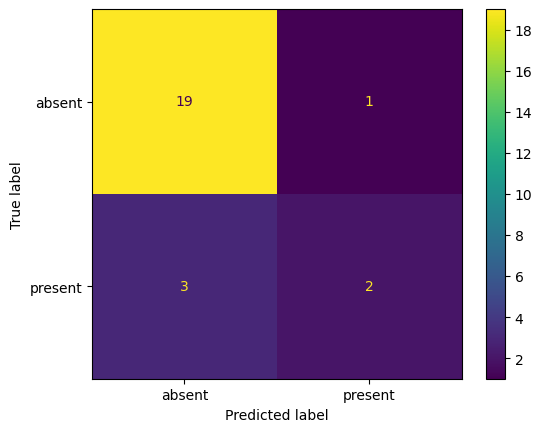

In [374]:
ConfusionMatrixDisplay.from_predictions(y_test,
                                        y_pred,
                                        display_labels=uniq_labels
                                       )

#### ... or using the fitted model and test data.

This approach avoids needing to compute the predicted classes, but **be sure to fit!**

#### Confusion matrix from labels (good)

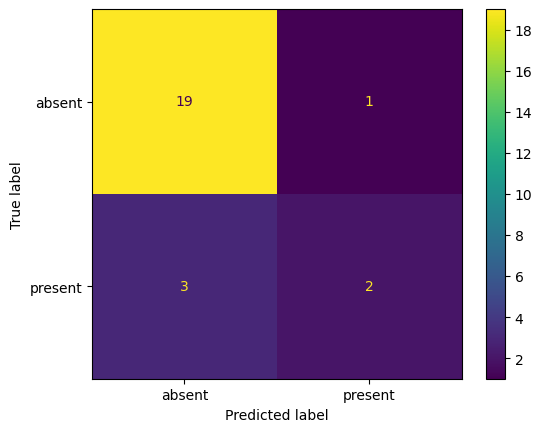

In [375]:
ConfusionMatrixDisplay.from_predictions(le.inverse_transform(y_test),
                                        le.inverse_transform(y_pred),
                                        display_labels=uniq_labels
                                       )

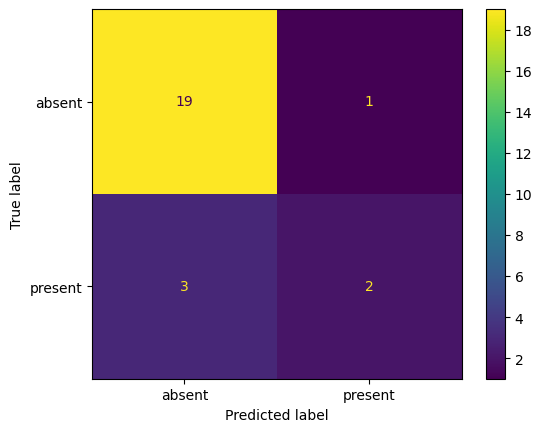

In [376]:
log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, display_labels=uniq_labels)

### Using the confusion matrix entries to compute metrics.

We can use the entries as shown below.

In [377]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel().tolist()
(tn, fp, fn, tp)

(19, 1, 3, 2)

#### Example - Computing the sensitivity

The [wikipedia page on sensitivity and specificity](https://en.wikipedia.org/wiki/Sensitivity_and_specificity) states that

1. $sensitivity = \frac{tp}{tp + fn}$
2. *Sensitivity refers to the test's ability to correctly detect ill patients out of those who do have the condition.*

In [378]:
(sensitivity := tp / (tp + fn))

0.4

<font color="orange">
When using logistic regression to estimate the presense of Kyphosis, the resulting model will correctly classify 60% of the subjects that truely have the condition.
</font>

## <font color="red"> Exercise 1 </font>

Compute the interpret the specificity when using Naive bayes as a classifier.

1. $specificity = \frac{tn}{tn + fp}$
2. *Specificity refers to the test's ability to correctly reject healthy patients without a condition*

In [379]:
(bayes := GaussianNB())

,priors,None
,var_smoothing,1e-09


In [380]:
bayes.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [381]:
(y_bayes_pred := bayes.predict(X_test))

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0])

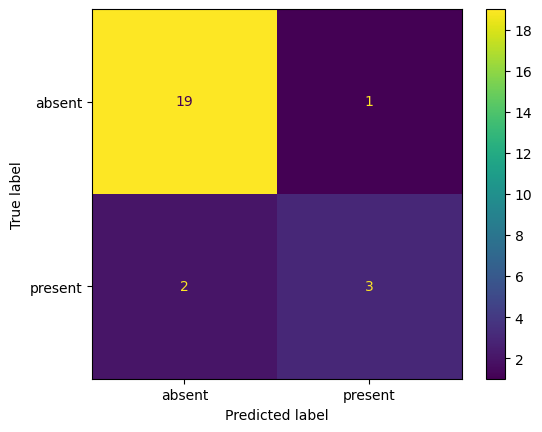

In [382]:
ConfusionMatrixDisplay.from_predictions(le.inverse_transform(y_test),
                                        le.inverse_transform(y_bayes_pred),
                                        display_labels=uniq_labels
                                       )

In [383]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel().tolist()
(tn, fp, fn, tp)

(19, 1, 3, 2)

In [384]:
# Your code here (add cells as needed)
(specificity := tn / (tn + fp))

0.95

<font color="orange">
When using logistic regression to estimate the presense of Kyphosis, the resulting model will correctly classify 95% of the subjects that truely do not have the condition..
</font>

## Confusion matrics after a grid search

When our model has tuning parameters, we need

1. To perform a grid search first, then
2. Use the resulting gird search object as the "model".

In [385]:
kNN = KNeighborsClassifier()
grid_knn = {'n_neighbors':list(range(3,12, 2))}

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_knn = GridSearchCV(kNN, grid_knn, cv=folds, scoring='roc_auc')
grid_search_knn.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


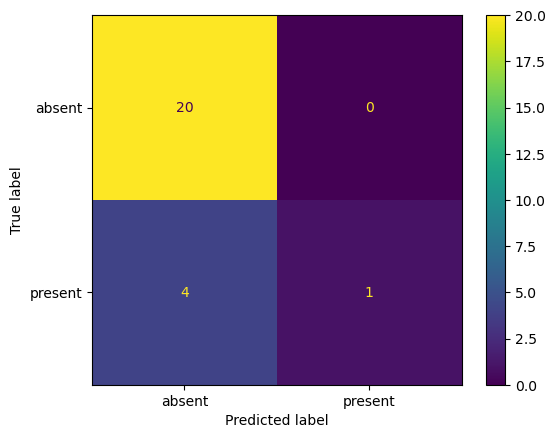

In [386]:
ConfusionMatrixDisplay.from_estimator(grid_search_knn,
                                      X_test,
                                      y_test,
                                      display_labels=uniq_labels)

In [387]:
y_pred_knn = grid_search_knn.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_knn).ravel().tolist()

In [388]:
(sensitivity := tp / (tp + fn))

0.2

<font color="orange">
When using logistic regression to estimate the presense of Kyphosis, the resulting model will correctly classify 0% of the subjects that truely have the condition.
</font>

In [389]:
(sensitivity := tp / (tp + fn))

0.2

<font color="orange">
When using logistic regression to estimate the presense of Kyphosis, the resulting model will correctly classify 60% of the subjects that truely have the condition.
</font>

## Topic 2 - ROC curves

The [ROC curve](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) is a way of

1. visualizing the performance of a classifier,
2. determining the best "cut-off" value when mistakes are penalized in different ways, and
3. Visually comparing the performance of a model.

Let's look at plotting ROC curves using `sklearn`

### Plotting a single ROC curve (no tuning parameters).

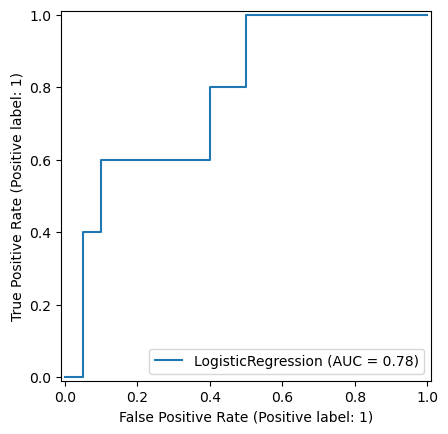

In [414]:
# Using the fitted model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

log_reg_disp = RocCurveDisplay.from_estimator(log_reg, X_test, y_test)

#### Plotting a single ROC curve (with tuning paramters).

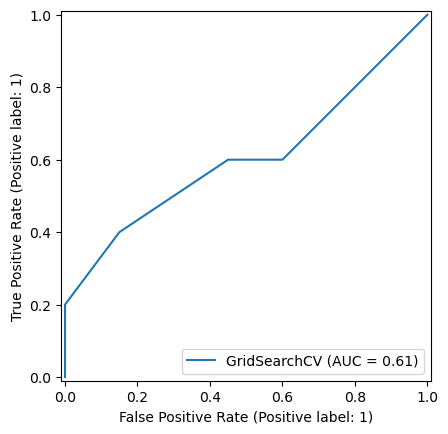

In [413]:
kNN = KNeighborsClassifier()
grid_knn = {'n_neighbors':list(range(3,12, 2))}

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_knn = GridSearchCV(kNN, grid_knn, cv=folds, scoring='roc_auc')
grid_search_knn.fit(X_train, y_train)

knn_disp = RocCurveDisplay.from_estimator(grid_search_knn, X_test, y_test)



#### Overlaying multiple ROC curves

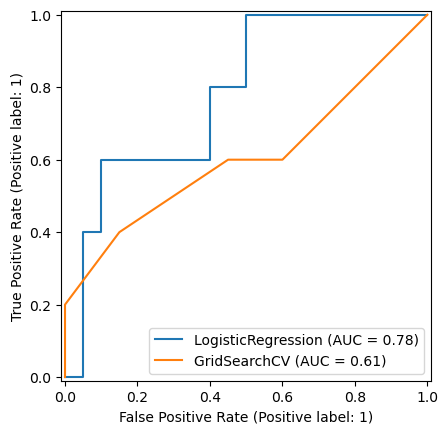

In [392]:
ax = plt.gca()
log_reg_disp.plot(ax=ax)
knn_disp.plot(ax=ax)

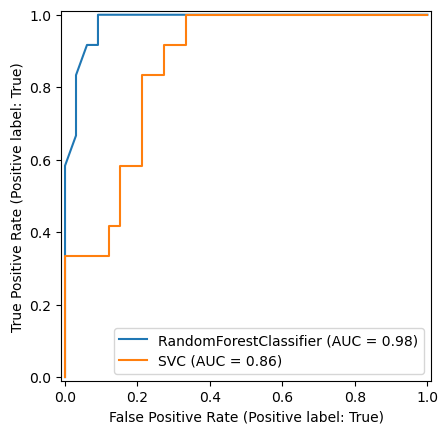

In [395]:
rfc = RandomForestClassifier(n_estimators=10, random_state=42)
rfc.fit(X_train, y_train)
ax = plt.gca()
rfc_disp = RocCurveDisplay.from_estimator(
    rfc, X_test, y_test, ax=ax)
svc_disp.plot(ax=ax)
plt.show()

## ROC curves for cross validation

While it is possible to plot ROC curves for cross validation, `sklearn` lacks the tools to do this easily.  [This example](https://ogrisel.github.io/scikit-learn.org/sklearn-tutorial/auto_examples/plot_roc_crossval.html) illustrates how this might be accomplished with VERY UGLY CODE!

## <font color="red"> Exercise 2</font>

Make a plot of all five ROC curves, one for each of the classic classifiers and interpret the results.

In [415]:
bayes = GaussianNB()
bayes.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


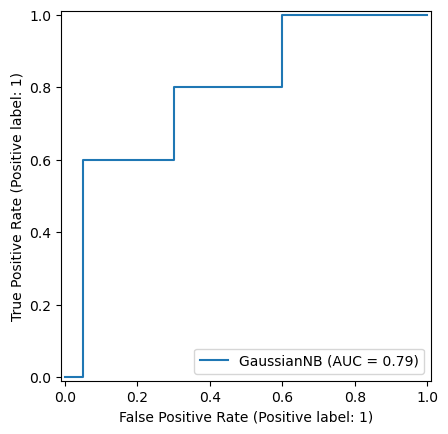

In [416]:
bayes_disp = RocCurveDisplay.from_estimator(bayes, X_test, y_test)

In [417]:
log_reg_ex2 = LogisticRegression(max_iter=1000)
log_reg_ex2.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


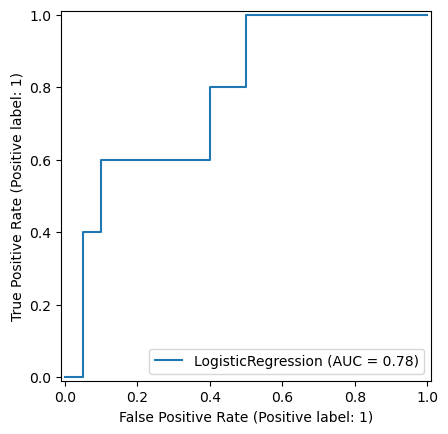

In [418]:
LogReg_disp = RocCurveDisplay.from_estimator(log_reg_ex2, X_test, y_test)

In [419]:
lda_ex2 = LinearDiscriminantAnalysis()
lda_ex2.fit(X_train, y_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


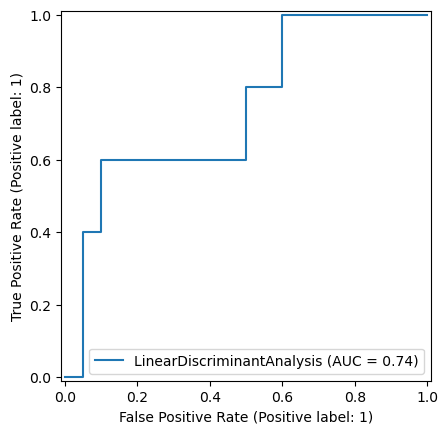

In [420]:
LDA_disp = RocCurveDisplay.from_estimator(lda_ex2, X_test, y_test)

In [421]:
qda_ex2 = QuadraticDiscriminantAnalysis()
qda_ex2.fit(X_train, y_train)

,priors,None
,reg_param,0.0
,store_covariance,False
,tol,0.0001


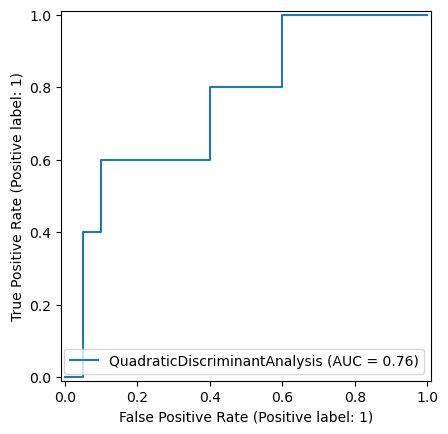

In [422]:
QDA_disp = RocCurveDisplay.from_estimator(qda_ex2, X_test, y_test)

In [423]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_knn2 = GridSearchCV(kNN, grid_knn, cv=folds, scoring='roc_auc')
grid_search_knn2.fit(X_train, y_train)
(y_pred_knn2 := grid_search_knn2.predict(X_test))

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0])

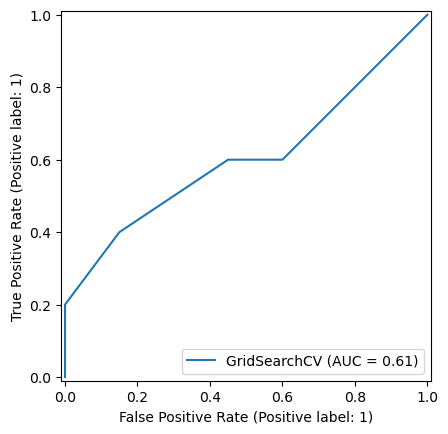

In [424]:
knn_disp = RocCurveDisplay.from_estimator(grid_search_knn2, X_test, y_test)

Text(0.5, 1.0, 'ROC Curves for All Models')

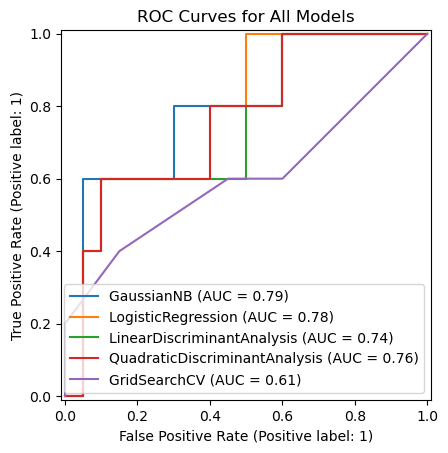

In [425]:
ax = plt.gca()
bayes_disp.plot(ax=ax)
LogReg_disp.plot(ax=ax) 
LDA_disp.plot(ax=ax)
QDA_disp.plot(ax=ax)
knn_disp.plot(ax=ax)
plt.title("ROC Curves for All Models")

#### THe gaussian AUC is the winning model by the metric AUC that measures at 0.79 narrowly beating Logisitic Regression at .78. 

## <font color="red"> Exercise 3 - Add to Lab 3.1</font>

For the `diabetes_raw.csv` data, do each of the following.

1. Plot the confusion matrix for each of the classic classification methods, and
3. Identify the model with the best value of those metrics, and interpret these winning values in the context of the problem. THE LDA MODEL
2. Compute the sensitivity and specificity of each for winning model
4. Make a visualization of the ROC curves overlaid on each plot.

# IN OTHER FULL LAB NOTEBOOK!

In [426]:
(diabetes := pl.read_csv('./data/diabetes_raw.csv'))

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes
i64,i64,i64,i64,i64,f64,f64,i64,str
6,148,72,35,0,33.6,0.627,50,"""Yes"""
1,85,66,29,0,26.6,0.351,31,"""No"""
8,183,64,0,0,23.3,0.672,32,"""Yes"""
1,89,66,23,94,28.1,0.167,21,"""No"""
0,137,40,35,168,43.1,2.288,33,"""Yes"""
…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,"""No"""
2,122,70,27,0,36.8,0.34,27,"""No"""
5,121,72,23,112,26.2,0.245,30,"""No"""


In [ ]:
(X_dia :=
 diabetes .select(cs.exclude('Outcome')))